# **Neural Networks for evaluating the magnetizations of a spin system**

## **The Ising Model**

The Ising model is focused on studying the dynamics of a grid of spins. The classical formulation of such model provides a set of spins $\{s_i \}_{i=1}^N$ which are binary variables, assuming values in the $\{\pm 1 \}$ range. In a 2D fashion, such grid can be seen as

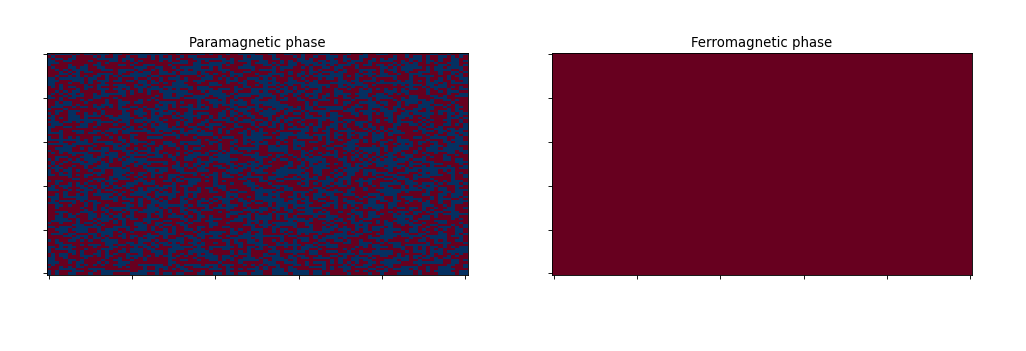

In the first image, we see al the spins in a disordered fashion, which means they are randomly aligned $+1$ or $-1$. Such phase of magnetic matter is called paramagnetic. In the second picture, all the spins are aligned, say, in a $+1$ orientation.

The magnetization $M$ of the system yields the sum over all the spins of the system: the magnetization over the number of spins, $m=M/N$, for $N \to \infty$ can assume all values in a range $[-1,1]$:

\begin{equation}
  m = \frac{1}{N} \sum_i s_i
\end{equation}

In a ferromagnetic phase, the average value for the magnetization, $\langle m \rangle$, is supposed to be $\pm 1$, while in a paramagnetic phase $\langle m \rangle = 0$.

As the number of spins amounts to $N$, for a 2D lattice it is possible to call $n=\sqrt N $ the linear size of the grid, with $N$ of course required to be a square number.

The Hamiltonian (i.e. the energy function of the system) reads as

\begin{equation}
 H = - J \sum_{\langle i j \rangle} s_i s_j - B \sum_i s_i
\end{equation}

where $\langle ij \rangle$ specifies the interaction between neighest neigbors: in a 1D interaction, each $i$-th spin interacts with the $i-1$ and $i+$ ones. On the contrary, in a 2D interaction, the $s_i$ spin neighbors with both $s_{i+1}$ and $s_{i-1}$, but even with the spins above and below: recalling $m$ to be the linear size of the spin matrix in figure, $s_{i}$ will interact as well with $s_{i+n}$ and $s_{i-n}$. Therefore, the neighborhood of $i$, in a 2D system, features $i\pm 1$ and $i\pm n$: $\langle i \rangle = \{ i+1, i-1, i+n, i - n \}$.



In the thermodynamics of multi-particle systems, the probability to find the system in a specific $\{ s \}_l$ configuration (as the two examples above in figure) is given by

\begin{equation}
P(\{s\}_l) = \frac{\exp({-H(\{s\}_l)/T)}}{Z}
\end{equation}

where $T$ is the temperature of the system and $Z$ is called partition function: as all the probabilities normalize to $1$, $Z$ is nothing but the sum (or the integral, for continuous systems) over all the $\{ s \}_l$ configurations:

\begin{equation}
Z = \sum_l \exp(-H(\{ s \}_l)/T)
\end{equation}

Take notice, we are summing over the $\{ s \}_l$ configurations, not over the $s_i$ spins.



In the limit $T\to \infty$, all the configurations are equiprobable, no matter about the energy value. Indeed,

\begin{equation}
\lim_{T \to +\infty} P(\{ s \}_l) = \lim_{T \to +\infty} \frac{\exp(-H(\{s\}_l)/T)}{Z} = \frac{1}{Z}
\end{equation}

i.e. the system can be found in any $\{ s \}_l$ configuration with the same $1/Z$ probability. Therefore, a ferromagnetic state is higly improbabile to be found at $T>>1$. On the contrary, for $T \to 0^+$ the system will be set in a state with an energy minimum: calling $E_0$ the energy of the ground state and $E>E_0$ any other energy of the system, for $T \to 0^+$

\begin{equation}
\exp(-\frac{E}{T}) = o\left(\exp(-\frac{E_0}{T})\right)
\end{equation}

and referring to the Ising energy model by $H$, the ground state $E_0$ is given when all the spins are aligned along with the direction (or at least the sign) of $B$.

## **A simple Neural Network: feed-forward with linear activation functions**

The first model of Neural Network we're going to work with is the feed-forward, with a single layer (connecting the inputs with the outputs) and linear activation functions. In practice, we are implementing a linear, or better, an affine transformation:

\begin{equation}
   y_j = \sum_{i} W_{ij} x_i + b_i
\end{equation}

We want now to employ this model to compute the magnetization for an Ising system: recalling the definition for $M$, it is simple to predict the weights of our feed-forward model:

\begin{equation}
  W_{ij} = +1, \quad
  b_i = 0
\end{equation}

The architecture of the system, implying a single output (the magnetization) will have $N$ inputs (the number of spins in the system) and $1$ output:

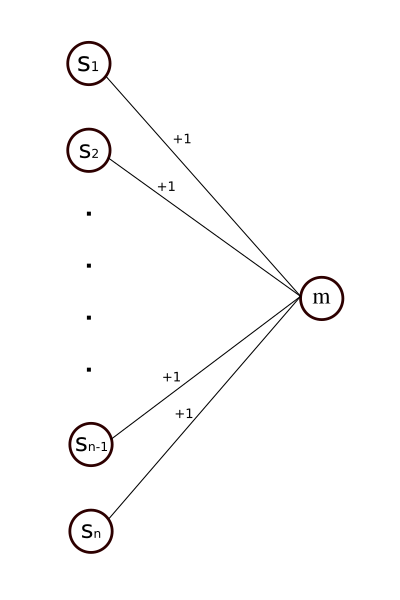

In fact, we're just evaluating a scalar product $\langle \vec W \cdot \vec s ⟩$, where $\vec s$ is the vector containing all the spin values, while $\vec W$ is a vector of $1$ elements. If instead we want to compute $m=M/N$, the weights $W_{1j}$ will be tuned as $1/N$.

## HANDS-ON: Training a Feed Forward Neural Network for linear regression

**Goal**: the purpose of this exercise is to train a NN to predict the magnetization value. Given a specific $\{s \}_l$ configuration, the Feed-Forward model should be able to return the corresponding $m$ value.

**Steps**


1.   Instantiate the FeedForward class template
2.   Load the dataset (already in the main file)
3.   Split the dataset into a training and a testing batches
4.   Train the model
5.   Evaluate the model performances during the test on the sub-dataset





**Hints**



1.   Recycle the FeedForward class template from the parabola exercise, rearranging the NN architecture
2.   To implement the NN architecture, you may take inspiration from the above figure. The number of inputs is given by the number of cells from the data, and the output is equal to 1 (the magnetization value).
3.   When performing a regression, the best choice for the loss function usually is the MSE loss.
4.   Remember: to compute magnetization, no activation function is required.
5.   To split the test and training dataset, you may use the following method:

```
from sklearn.model_selection import train_test_split

data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size=0.3)
```





In [1]:
## Import libraries ##
import numpy as np
import sys

import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split

In [2]:
## Class Template ##
class FeedForwardNN(nn.Module):
    def __init__(self, input_size,nh, output_size):
        super().__init__()

        # TODO:  DEFINE HERE THE LAYERS
        self.model = nn.Sequential(nn.Linear(input_size, nh),
                                    nn.ReLU(),
                                    nn.Linear(nh,output_size))
        # TODO: DEFINE HERE THE OPTIMIZER
        self.optimizer = torch.optim.SGD(self.model.parameters(),lr=0.001)
        # TODO: DEFINE HERE THE LOSS
        self.criterion = nn.MSELoss()
    def forward(self, x):
        output = self.model(x)
        return output

    def train_step(self, inputs, labels):
        """

        :param inputs:
        :param labels:
        :return:
        """

        # zero the parameter gradients
        self.optimizer.zero_grad()

        # forward + backward + optimize
        outputs = self.model(inputs)
        labels = labels.unsqueeze(1)
        loss = self.criterion(outputs, labels)
        loss.backward()
        self.optimizer.step()

        return loss.item()

In [4]:
## main function ##
def main():

    # Load the dataset
    path = '/ISING_1000step.npz'
    with np.load(path) as loader:
      raw_data = np.load("ISING_1000step.npz")
    x_data, y_data = raw_data["grid"], raw_data["magnetizations"]
    sys.exit()

    # Convert to tensor
    labels = torch.tensor(y_data, dtype=torch.float32)
    data = torch.tensor(x_data, dtype=torch.float32)

    # get the number of features (len_data, n_features)
    _, input_size = data.size()
    output_size = 1

    # We split the dataset into a training dataset and a test dataset. The former is used to train the model, while the
    # latter is used to evaluate the model performance
    # TODO: split the data into a training and a testing datasets (use "train_test_split" from sklearn.model_selection)
    # For further info: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
    data_train, data_test, labels_train, labels_test = train_test_split(data, labels, test_size = 0.2, stratify = labels, random_state=42)
    # Create dataset from several tensors with matching first dimension
    # Samples will be drawn from the first dimension (rows)
    dataset_train = TensorDataset(data_train, labels_train)

    # Create a data loader from the dataset
    # Batch size and number of workers are specified at this step
    loader_train = DataLoader(dataset_train, batch_size=16, shuffle=True)

    # We define the NN model
    # TODO: initialize the NN model
    network = FeedForwardNN(input_size=input_size, nh = 20, output_size=output_size)
    network.train()
    total_loss = 0
    # Train model
    for epoch, data in enumerate(loader_train):
        input_data, label = data

        # TODO: train the model
        loss = network.train_step(input_data,label)
        total_loss+=loss
    #TODO: test the performance of the model using the test dataset
    network.eval()
    with torch.no_grad():
       preds = network(data_test)
       labels_test = labels_test.unsqueeze(1)
       mse = ((preds - labels_test)**2).mean()
    return mse

In [5]:
ising = main()

FileNotFoundError: [Errno 2] No such file or directory: 'ISING_1000step.npz'

# Supplementary Material: Binary Classification for Ising Model

The Ising model provides an interesting example of second order phase transitions, or continous phase transitions. Indeed, evolving with $T$ the spin configurations smoothly vary from the ferromagnetic to the paramagnetic phase and vice versa. A scheme for such phase transition is provided in figure:

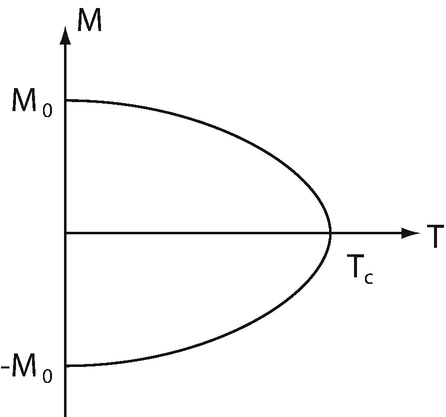

Increasing with the temperature, the magnetization (both positive or negative, depending on the spin alignment) gradually decrease to zero. At $T=T_c$ (where $T_c$ stands for the critic temperature) the averaged value for $m$ is equal to zero. Therefore, there is no neat distinction between paramagnetic and ferromagnetic phase, as it happens for other phases of matter (the most notorious being the liquid and solid phases of $H_2O$).

As an exercise of classification, it is possible to set a parameter $c=0.5$, so that if $m<c$ we will consider the Ising configuration to be paramagnetic, otherwise a ferromagnetic one.

For a binary classification, the Binary Cross-Entropy loss function well fits our purpose. Secondly, instead of a linear regression, we need to perform a different task: one additional layer, linked by Tanh and Sigmoid activation functions with the input and output layers, should work fine. The class template thus modifies as follows:

In [ ]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        self.model = nn.Sequential(nn.Linear(input_size, 20),
                                   nn.Tanh(),
                                   nn.Linear(20, output_size),
                                   nn.Sigmoid())

        self.optimizer = optim.Adam(self.model.parameters(), lr=0.01)
        self.criterion = nn.BCELoss()

The other methods remaining unaltered. The next step consists of switching the labels from the $[-1;1]$ range to the $\{0,1\}$ values ($0$ being paramagnetic, $1$ ferromagnetic in our convenctions). Such transformation is easily implemented in python by the following syntax:

In [ ]:
labels[labels > 0.5] = 1
labels[labels <= 0.5] = 0

Eventually, as more layers, along with non-linear activation functions are involved, more training may be required. Such achievement can be obtained by slightly modifying the training module in the main function:

In [ ]:
# Train model
for epoch in range(n_epochs):
    for data in loader_train:
        input_data, label = data
        loss = NN_model.train_step(input_data, label)
        print("epoch: {}, loss: {}".format(epoch, loss))

with n_epochs to be specified as a parameter of the simulation. You may find the full code in the colab files.